# Powerplay and Death Overs Analysis

In T20 cricket, different phases of the innings require different strategies.

The powerplay overs often determine the foundation of an innings, while the death overs frequently influence the final outcome of the match.

This analysis investigates team performance during these critical phases to identify scoring patterns, strategic advantages, and performance differences across IPL franchises.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [2]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

# Business Question 1

## Which Teams Score The Most Runs During The Powerplay?

The first six overs of a T20 innings are played under fielding restrictions, creating opportunities for aggressive batting.

This analysis identifies the teams that have been most successful at maximizing scoring during the powerplay phase.

In [3]:
powerplay = deliveries[
    deliveries['over'] <= 5
]

In [4]:
powerplay_runs = (
    powerplay
    .groupby('batting_team')
    .agg(
        Powerplay_Runs=('total_runs','sum')
    )
    .sort_values(
        'Powerplay_Runs',
        ascending=False
    )
)

powerplay_runs.head(10)

,Powerplay_Runs
batting_team,
Mumbai Indians,12225
Delhi Capitals,12069
Kolkata Knight Riders,11941
Punjab Kings,11795
Royal Challengers Bengaluru,11795
Chennai Super Kings,10991
Rajasthan Royals,10226
Sunrisers Hyderabad,8937
Deccan Chargers,3417


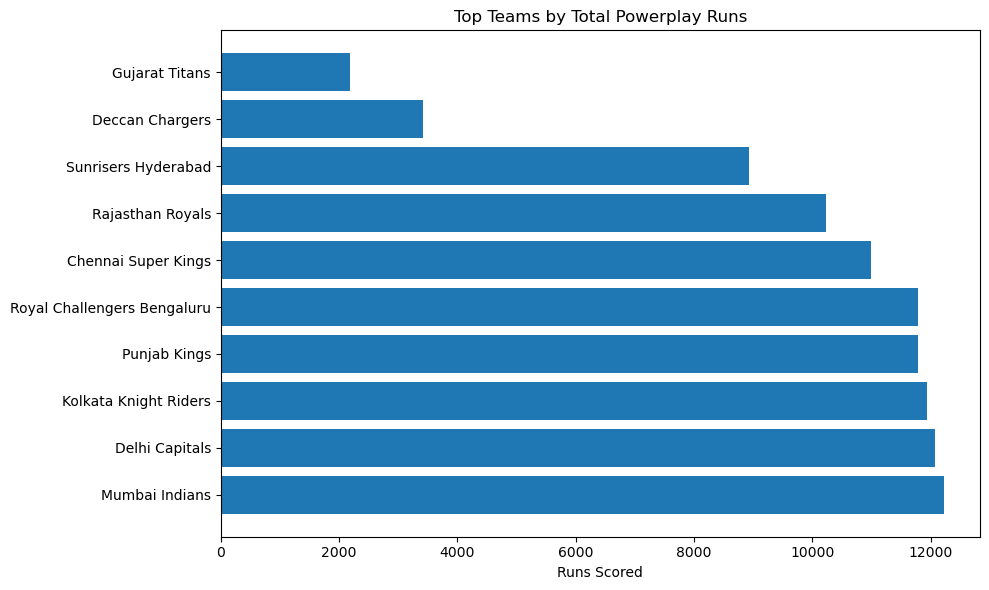

In [5]:
top_powerplay = powerplay_runs.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_powerplay.index,
    top_powerplay['Powerplay_Runs']
)

plt.title('Top Teams by Total Powerplay Runs')
plt.xlabel('Runs Scored')

plt.tight_layout()
plt.show()

## Insight

Teams that consistently score heavily during the powerplay establish stronger foundations for competitive totals and successful run chases.

Higher powerplay scoring rates can reduce pressure on middle-order batters and improve overall run-scoring potential throughout the innings.

# Business Question 2

## Which Teams Score The Most Runs During Death Overs?

The final overs of a T20 innings are often the most influential phase of the game.

Teams capable of accelerating scoring during overs 16 to 20 can significantly increase winning probabilities and defend larger totals.

In [6]:
death_overs = deliveries[
    deliveries['over'] >= 15
]

In [7]:
death_runs = (
    death_overs
    .groupby('batting_team')
    .agg(
        Death_Over_Runs=('total_runs','sum')
    )
    .sort_values(
        'Death_Over_Runs',
        ascending=False
    )
)

death_runs.head(10)

,Death_Over_Runs
batting_team,
Mumbai Indians,11889
Royal Challengers Bengaluru,11330
Chennai Super Kings,11094
Punjab Kings,10475
Delhi Capitals,10179
Kolkata Knight Riders,10123
Rajasthan Royals,9133
Sunrisers Hyderabad,7672
Deccan Chargers,3133


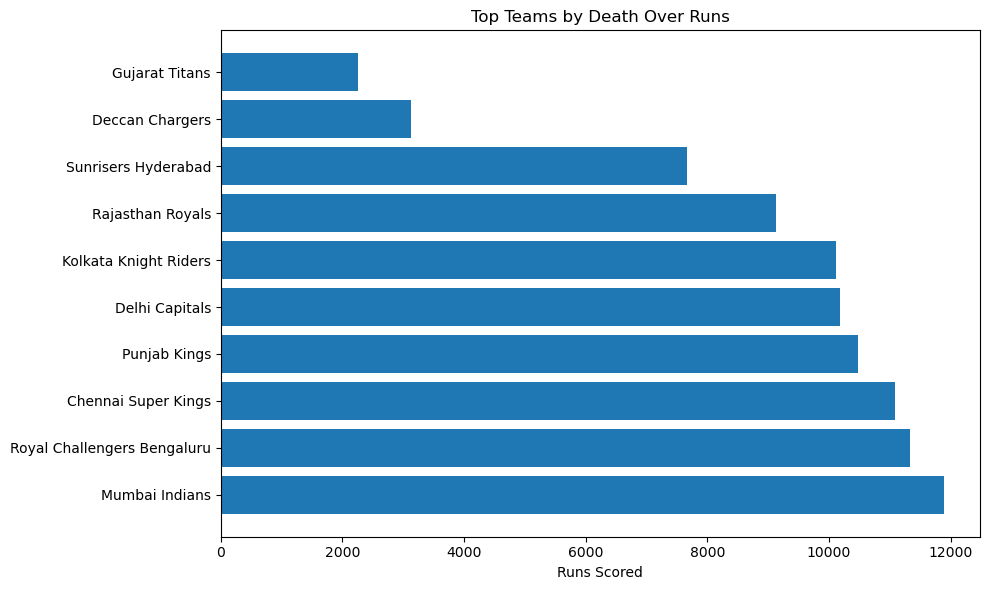

In [8]:
top_death = death_runs.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_death.index,
    top_death['Death_Over_Runs']
)

plt.title('Top Teams by Death Over Runs')
plt.xlabel('Runs Scored')

plt.tight_layout()
plt.show()

## Analytical Consideration

Total runs can be influenced by the number of matches played by a franchise.

To ensure fair comparisons, average runs per innings will be analyzed in addition to cumulative totals.

This approach helps identify which teams are most effective during specific phases of an innings rather than simply identifying teams that have participated in more matches.

## Refining the Analysis

While total powerplay and death-over runs provide a high-level view of team performance, they can be heavily influenced by the number of matches a team has played.

Teams such as Mumbai Indians, Chennai Super Kings, and Kolkata Knight Riders have participated in significantly more IPL matches than newer franchises, naturally leading to higher cumulative run totals.

To enable fair comparisons across teams, the analysis will now focus on average runs scored per innings during each phase of the game.

This approach provides a better measure of scoring efficiency and allows performance to be compared on a like-for-like basis.

In [9]:
powerplay_innings = (
    powerplay
    .groupby(['match_id', 'inning', 'batting_team'])
    ['total_runs']
    .sum()
    .reset_index()
)

powerplay_avg = (
    powerplay_innings
    .groupby('batting_team')
    .agg(
        Avg_Powerplay_Runs=('total_runs', 'mean'),
        Innings=('total_runs', 'count')
    )
    .sort_values(
        'Avg_Powerplay_Runs',
        ascending=False
    )
)

powerplay_avg

,Avg_Powerplay_Runs,Innings
batting_team,,
Gujarat Lions,50.290323,31
Kochi Tuskers Kerala,48.571429,14
Gujarat Titans,48.533333,45
Sunrisers Hyderabad,48.048387,186
Rising Pune Supergiants,47.433333,30
Lucknow Super Giants,47.272727,44
Delhi Capitals,47.144531,256
Punjab Kings,46.992032,251
Kolkata Knight Riders,46.827451,255


## Death Overs Scoring Efficiency

The death overs often determine whether a team posts a competitive total or successfully accelerates during a chase.

Analyzing average death-over runs per innings helps identify teams that consistently finish innings strongly, regardless of the number of matches they have played.

In [10]:
death_innings = (
    death_overs
    .groupby(['match_id', 'inning', 'batting_team'])
    ['total_runs']
    .sum()
    .reset_index()
)

death_avg = (
    death_innings
    .groupby('batting_team')
    .agg(
        Avg_Death_Over_Runs=('total_runs', 'mean'),
        Innings=('total_runs', 'count')
    )
    .sort_values(
        'Avg_Death_Over_Runs',
        ascending=False
    )
)

death_avg

,Avg_Death_Over_Runs,Innings
batting_team,,
Gujarat Titans,51.250000,44
Lucknow Super Giants,49.023256,43
Chennai Super Kings,47.818966,232
Royal Challengers Bengaluru,47.605042,238
Mumbai Indians,47.366534,251
Rising Pune Supergiants,46.576923,26
Punjab Kings,44.574468,235
Sunrisers Hyderabad,44.091954,174
Deccan Chargers,43.513889,72


In [11]:
powerplay_avg[
    powerplay_avg['Innings'] >= 30
]

,Avg_Powerplay_Runs,Innings
batting_team,,
Gujarat Lions,50.290323,31
Gujarat Titans,48.533333,45
Sunrisers Hyderabad,48.048387,186
Rising Pune Supergiants,47.433333,30
Lucknow Super Giants,47.272727,44
Delhi Capitals,47.144531,256
Punjab Kings,46.992032,251
Kolkata Knight Riders,46.827451,255
Chennai Super Kings,46.180672,238


In [12]:
death_avg[
    death_avg['Innings'] >= 30
]

,Avg_Death_Over_Runs,Innings
batting_team,,
Gujarat Titans,51.250000,44
Lucknow Super Giants,49.023256,43
Chennai Super Kings,47.818966,232
Royal Challengers Bengaluru,47.605042,238
Mumbai Indians,47.366534,251
Punjab Kings,44.574468,235
Sunrisers Hyderabad,44.091954,174
Deccan Chargers,43.513889,72
Rajasthan Royals,43.490476,210


In [13]:
powerplay_avg_reliable = powerplay_avg[
    powerplay_avg['Innings'] >= 100
].sort_values(
    'Avg_Powerplay_Runs',
    ascending=False
)

powerplay_avg_reliable

,Avg_Powerplay_Runs,Innings
batting_team,,
Sunrisers Hyderabad,48.048387,186
Delhi Capitals,47.144531,256
Punjab Kings,46.992032,251
Kolkata Knight Riders,46.827451,255
Chennai Super Kings,46.180672,238
Mumbai Indians,45.958647,266
Rajasthan Royals,45.856502,223
Royal Challengers Bengaluru,45.717054,258


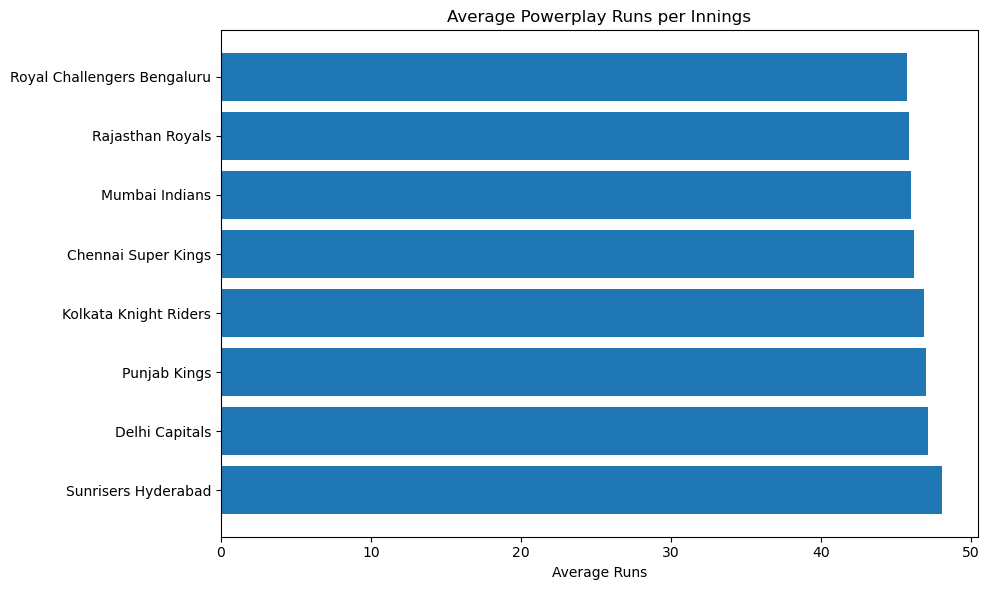

In [15]:
plt.figure(figsize=(10,6))

plt.barh(
    powerplay_avg_reliable.index,
    powerplay_avg_reliable['Avg_Powerplay_Runs']
)

plt.title('Average Powerplay Runs per Innings')
plt.xlabel('Average Runs')

plt.tight_layout()
plt.show()

## Insight: Powerplay Performance

After applying a minimum innings threshold, Sunrisers Hyderabad emerged as the strongest powerplay batting team, averaging approximately 48.0 runs during the first six overs.

Delhi Capitals, Punjab Kings, and Kolkata Knight Riders also demonstrated strong powerplay scoring efficiency, consistently exceeding 46 runs per innings.

Interestingly, the differences between the top-ranked teams are relatively small, suggesting that powerplay performance across leading IPL franchises is highly competitive.

The findings indicate that teams capable of maximizing fielding restrictions in the opening overs gain a valuable advantage by establishing stronger scoring platforms for the remainder of the innings.

In [14]:
death_avg_reliable = death_avg[
    death_avg['Innings'] >= 100
].sort_values(
    'Avg_Death_Over_Runs',
    ascending=False
)

death_avg_reliable

,Avg_Death_Over_Runs,Innings
batting_team,,
Chennai Super Kings,47.818966,232
Royal Challengers Bengaluru,47.605042,238
Mumbai Indians,47.366534,251
Punjab Kings,44.574468,235
Sunrisers Hyderabad,44.091954,174
Rajasthan Royals,43.490476,210
Kolkata Knight Riders,43.446352,233
Delhi Capitals,42.768908,238


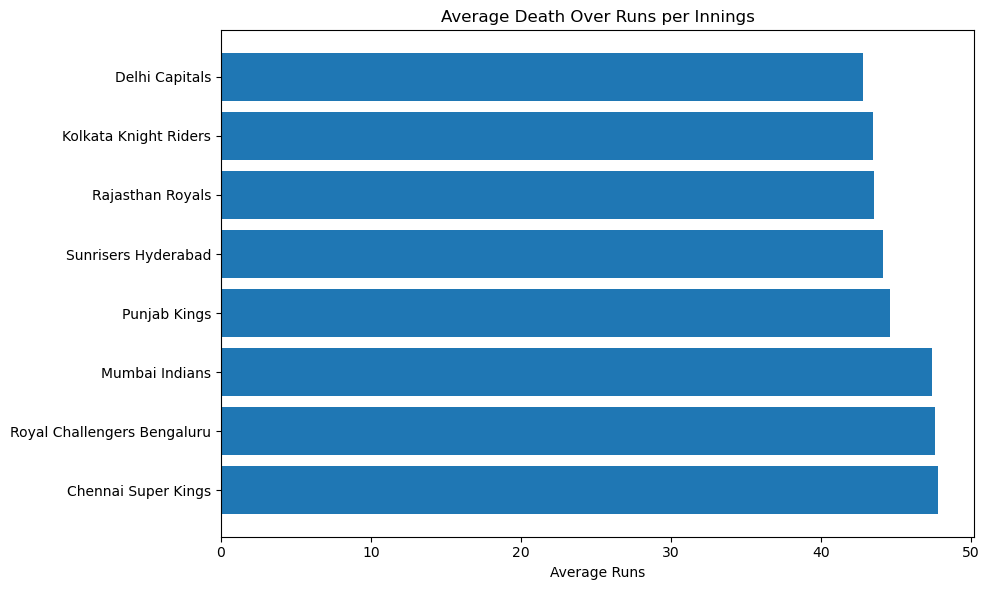

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    death_avg_reliable.index,
    death_avg_reliable['Avg_Death_Over_Runs']
)

plt.title('Average Death Over Runs per Innings')
plt.xlabel('Average Runs')

plt.tight_layout()
plt.show()

## Insight: Death Overs Performance

Chennai Super Kings recorded the highest average death-over scoring rate among established IPL franchises, averaging nearly 47.8 runs during overs 16 to 20.

Royal Challengers Bengaluru and Mumbai Indians followed closely, highlighting their ability to accelerate scoring during the most critical phase of a T20 innings.

The results suggest that successful IPL franchises often combine strong finishing ability with batting depth and effective power-hitting resources.

While the differences between the top teams are not dramatic, even a few additional runs during the death overs can significantly influence match outcomes in closely contested games.

## Comparative Analysis

Comparing powerplay and death-over performance reveals interesting differences in team strategies.

Sunrisers Hyderabad and Delhi Capitals demonstrate particular strength during the powerplay phase, focusing on strong starts and early momentum.

In contrast, Chennai Super Kings, Royal Challengers Bengaluru, and Mumbai Indians excel during the death overs, showcasing their ability to accelerate scoring and maximize run production late in the innings.

These differences suggest that successful IPL teams can achieve competitive advantages through different strategic approaches rather than relying on a single batting philosophy.

## Reliability Adjustment

Some franchises have participated in only a limited number of IPL seasons.

Small sample sizes can produce unusually high or low averages that may not accurately represent long-term performance.

To improve the reliability of comparisons, teams with fewer than 100 innings are excluded from the ranking.

This allows the analysis to focus on franchises with sufficient historical data.

# Powerplay and Death Overs Summary

This analysis examined team performance during the two most influential phases of a T20 innings: the powerplay and the death overs.

## Key Findings

- Sunrisers Hyderabad recorded the highest average powerplay scoring rate among established IPL franchises.
- Delhi Capitals, Punjab Kings, and Kolkata Knight Riders also demonstrated strong powerplay performance.
- Chennai Super Kings emerged as the strongest death-over batting team, closely followed by Royal Challengers Bengaluru and Mumbai Indians.
- Successful IPL teams often combine strong starts with effective finishing ability, although different franchises achieve success through different batting approaches.

## Strategic Insights

- Strong powerplay performances help establish momentum and create a platform for larger totals.
- Efficient death-over scoring can significantly increase match-winning opportunities by maximizing run production during the final overs.
- Teams may adopt different batting strategies while still achieving competitive success, highlighting the importance of flexibility and squad composition.

## Conclusion

The analysis demonstrates that phase-specific performance plays a critical role in T20 cricket.

While overall team quality remains important, the ability to capitalize on scoring opportunities during the powerplay and death overs can provide a meaningful competitive advantage and influence match outcomes.